<a href="https://colab.research.google.com/github/JCSR2022/challenge3-data-science-Alura/blob/main/data/Data_Preprocessing_Stage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Telecom X – Customer Churn Prediction

## Data Preprocessing Stage

### Project Context

Telecom X faces a critical business challenge: **customer churn**. Customer cancellations directly impact revenue stability, increase acquisition costs, and affect long-term growth.

The objective of this project is to develop **Machine Learning models capable of predicting which customers are most likely to cancel their services** before churn occurs.

This stage represents the transition from **exploratory data analysis to predictive modeling**, where the focus shifts to preparing the dataset to ensure reliable, interpretable, and high-performance models.

Some of this work was made on the Challenge 2 , but in this ocasion the focus will be on billding a pipeline that allow take this process to production.

---

# 🧠 Data Preprocessing Pipeline

The preprocessing stage prepares the raw dataset for Machine Learning modeling by cleaning, transforming, and selecting relevant features.


In [51]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# ================================
# 1. Load Data
# ================================

url_data = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data_raw = pd.read_json(url_data)
data = pd.json_normalize(data_raw.to_dict(orient="records"))

# ================================
# 2. Data Cleaning
# ================================

# keep valid target labels
data = data[data["Churn"].isin(["Yes", "No"])]

# convert numeric column
data["account.Charges.Total"] = pd.to_numeric(
    data["account.Charges.Total"], errors="coerce"
)

# remove invalid rows
data = data.dropna(subset=["account.Charges.Total"])

# encode target
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

# ================================
# 3. Feature / Target Split
# ================================

X = data.drop("Churn", axis=1)
y = data["Churn"]

# ================================
# 4. Custom Transformer
# ================================

class BinaryMapper(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.binary_map = {
            "customer.gender": {"Female": 0, "Male": 1},
            "customer.Partner": {"No": 0, "Yes": 1},
            "customer.Dependents": {"No": 0, "Yes": 1},
            "phone.PhoneService": {"No": 0, "Yes": 1},
            "phone.MultipleLines": {"No": 0, "Yes": 1, "No phone service": 0},
            "internet.OnlineSecurity": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.OnlineBackup": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.DeviceProtection": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.TechSupport": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.StreamingTV": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.StreamingMovies": {"No": 0, "Yes": 1, "No internet service": 0},
            "account.PaperlessBilling": {"No": 0, "Yes": 1}
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # remove ID
        X = X.drop("customerID", axis=1)

        for col, mapping in self.binary_map.items():
            X[col] = X[col].map(mapping)

        return X


# ================================
# 5. Feature Groups
# ================================

binary_features = [
    "customer.gender",
    "customer.SeniorCitizen",
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "phone.MultipleLines",
    "internet.OnlineSecurity",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies",
    "account.PaperlessBilling"
]

categorical_onehot = [
    "internet.InternetService",
    "account.Contract",
    "account.PaymentMethod"
]

numeric_features = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total"
]

# ================================
# 6. Column Transformer
# ================================

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), categorical_onehot),
        ("num", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features)
    ]
)

# ================================
# 7. Full Pipeline
# ================================

pipeline = Pipeline(
    steps=[
        ("binary_mapper", BinaryMapper()),
        ("preprocessor", preprocessor)
    ]
)

# ================================
# 8. Train / Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 9. Fit Pipeline
# ================================

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (5625, 26)
Test shape: (1407, 26)


In [53]:
def get_processed_dataframe(pipeline, X):

    # apply the pipeline
    X_transformed = pipeline.transform(X)

    # get column names from the preprocessor
    preprocessor = pipeline.named_steps["preprocessor"]

    feature_names = preprocessor.get_feature_names_out()

    # create dataframe
    df_processed = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X.index
    )

    return df_processed

# Fit pipeline
pipeline.fit(X_train)

# Get transformed dataframe
df_train_processed = get_processed_dataframe(pipeline, X_train)

display(df_train_processed.head())

,onehot__internet.InternetService_DSL,onehot__internet.InternetService_Fiber optic,onehot__internet.InternetService_No,onehot__account.Contract_Month-to-month,onehot__account.Contract_One year,onehot__account.Contract_Two year,onehot__account.PaymentMethod_Bank transfer (automatic),onehot__account.PaymentMethod_Credit card (automatic),onehot__account.PaymentMethod_Electronic check,onehot__account.PaymentMethod_Mailed check,...,binary__customer.Dependents,binary__phone.PhoneService,binary__phone.MultipleLines,binary__internet.OnlineSecurity,binary__internet.OnlineBackup,binary__internet.DeviceProtection,binary__internet.TechSupport,binary__internet.StreamingTV,binary__internet.StreamingMovies,binary__account.PaperlessBilling
1457,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7226,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
3523,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4702,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
3715,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


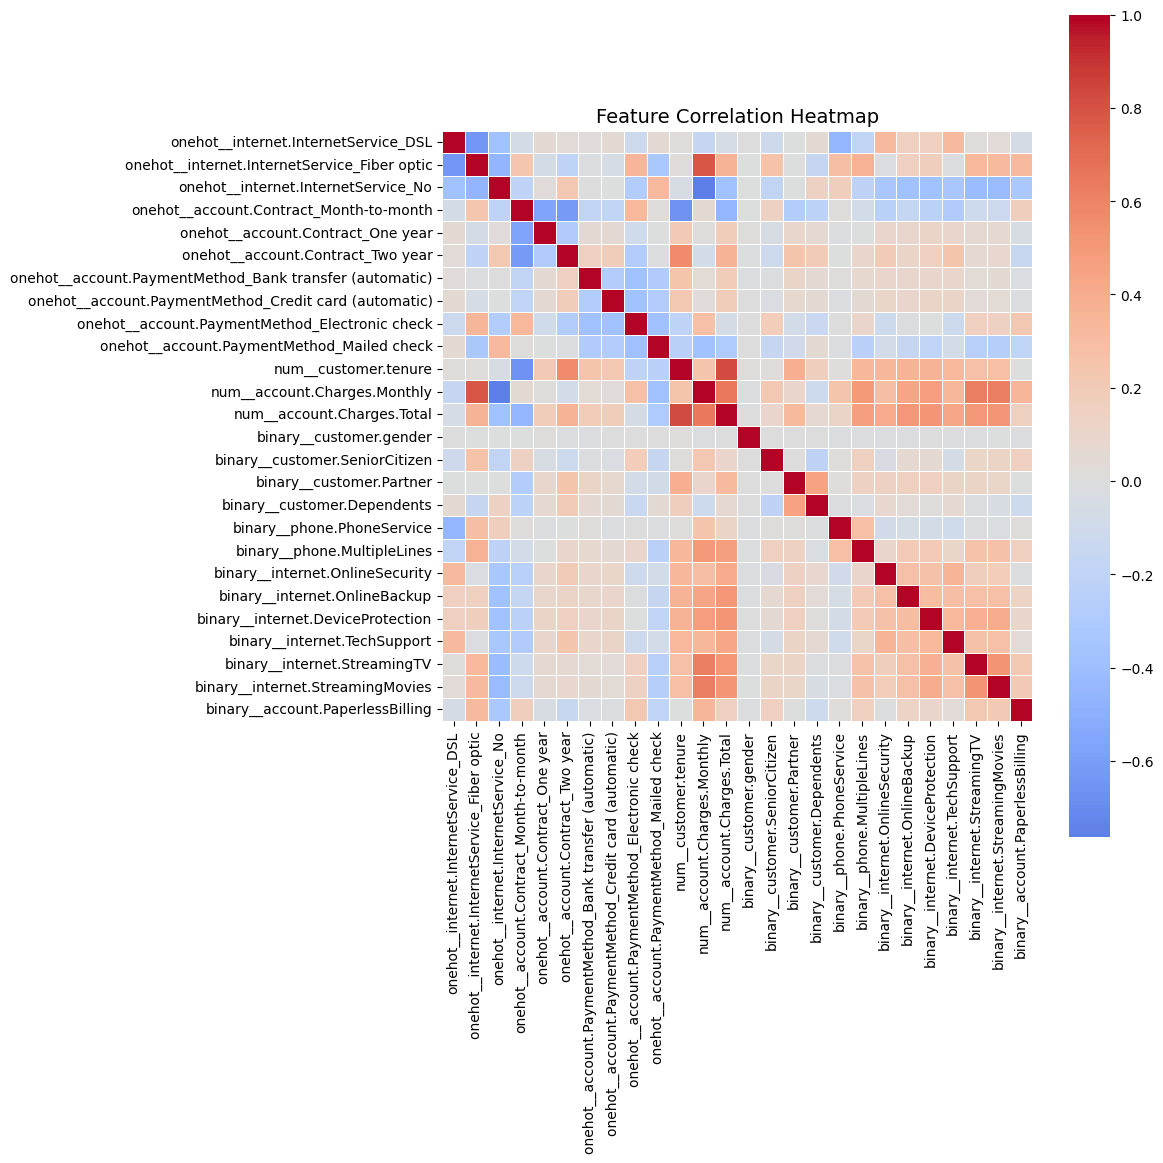

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(df, target=None, top_n=None, figsize=(12,12)):
    """
    Plot a correlation heatmap of a dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing numeric features.

    target : str, optional
        Target column to sort correlations by.

    top_n : int, optional
        Number of top correlated features with the target to visualize.

    figsize : tuple
        Size of the plot.
    """

    corr = df.corr()

    # If a target is specified, sort features by correlation
    if target is not None:

        corr_target = corr[target].abs().sort_values(ascending=False)

        if top_n is not None:
            selected_features = corr_target.head(top_n).index
            corr = corr.loc[selected_features, selected_features]

    plt.figure(figsize=figsize)

    sns.heatmap(
        corr,
        #annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5
    )

    plt.title("Feature Correlation Heatmap", fontsize=14)
    plt.tight_layout()
    plt.show()
plot_correlation_heatmap(df_train_processed)

In [ ]:
# ================================
# 10. saving data
# ================================
import joblib


df_train_processed.to_csv("df_train_processed.csv", index=False)

df_test_processed = get_processed_dataframe(pipeline, X_test)
df_test_processed.to_csv("df_test_processed.csv", index=False)

joblib.dump(pipeline, "preprocessing_pipeline.joblib")


In [ ]:
#pipeline = joblib.load("preprocessing_pipeline.joblib")
#X_new_processed = pipeline.transform(X_new)